## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Will Morales

**Date:** 10/1/26

In [20]:
#Q1 referenced the class slides
#1 Regression predicts a number. Classification predicts a category.
#2 A confusion table or matrix counts predictions by actual class and predicted class. The diagonal cells are correct predictions and the off diagonal cells are misclassifications. The table helps us see where the model does well versus poorly.
#3 SSE is the sum of squared error. For each observation, the residual is the actual value minus the prediction, and SSE adds up the squared residuals. It quantifies the total size of the model's prediction errors.
#4 Overfitting is when a model fits the noise in the training data. Underfitting is when the model is too simple, so it gives nearly the same prediction for every observation.
#5 Choosing k by training error would pick a tiny k and overfit. Splitting the data lets me fit on the training set and check the accuracy or SSE on data the model hasn't seen, so we pick the k that generalizes best.
#6 A class label is easy to report, but it hides uncertainty, since a very tight vote looks the same as a landslide. A probability distribution shows hiw confident the model is and lets us pick a cutoff when errors cost different amounts, but it's tougher with a small k.



In [21]:
#Q2 imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

In [22]:
from google.colab import files
uploaded = files.upload()

Saving land_mines.csv to land_mines (1).csv


In [23]:
#1 EDA
df = pd.read_csv('land_mines.csv')
df.head()
print(df.shape)
print(df.isna().sum())
print(df[["voltage", "height", "soil"]].describe())

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000


In [24]:
#2 Split into 2
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.5, random_state=65, stratify=y)
#test size is 0.5 because split in half; stratify helps them be more even

2 0.46745562130177515


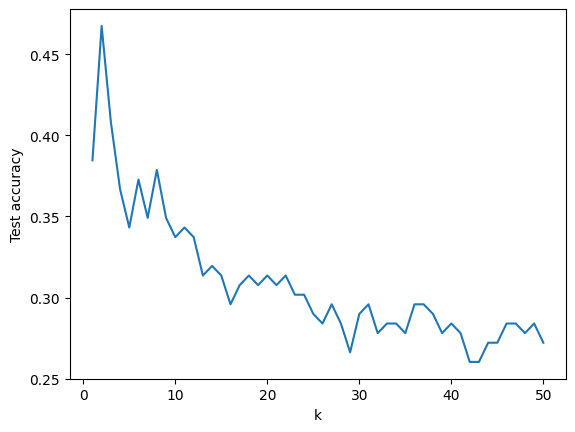

In [25]:
#3 building the model
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn scaling first
X_test_scaled = scaler.transform(X_test)         # apply same scaling to test

ks = np.arange(1, 51)
test_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train_scaled, y_train)
    test_acc.append(model.score(X_test_scaled, y_test))
    train_acc.append(model.score(X_train_scaled, y_train))

k_star = int(ks[np.argmax(test_acc)])
print(k_star, max(test_acc))

plt.plot(ks, test_acc)
plt.xlabel("k")
plt.ylabel("Test accuracy")
plt.show()
#How I selected K: #Chose 50 as the largest K to try because the slides used that but it also fits here because it is way larger than the best k but way smaller than 169.

In [26]:
#4 Confusion table
best_model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

# Building the table
print(pd.crosstab(y_test, y_pred, rownames=["Actual"], colnames=["Predicted"]))

# Accuracy test
print(np.mean(y_pred == y_test))


Predicted   1   2   3   4  5
Actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2
0.46745562130177515


In [27]:
#5
# The model can look good for one type of mine and still make a lot of mistakes.
# For example, it finds 27 of the 36 real type 1 mines (75%), which soujnds
# strong. But it predicted type 1 a total of 67 times, so only 27 of those
# predictions (about 40%) were right. Many type 3, 4, and 5 mines get called
# type 1. Overall accuracy is only about 47%, so mistakes are pretty common.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 8c679880df23b3522296bf029e9f2bb62ed99ffa
- **AI tool and model used:** Claude Sonnet

### *Prompts used



```
# This is formatted as code
```

1. Hey claude help em check my homework and improve my answers so I can learn how to improve my coding ability but don't get too fancy.
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Pick k without using the test set. Choose k with 5 fold cross validation on the training data only, then use the test set once at the end. This changes your answer from k=2 at 46.7% to k=9 at about 35%, which is a more honest estimate. If you keep the test set method because the assignment describes it, say in your write up that the result is optimistic and that k=2 is a lucky spike.
2. Fix the code issues. Define train_acc = [] before your loop, since it is currently missing, and plot train and test accuracy together so overfitting is visible. Also correct the typos in your comments ("hiw", "soujnds").
3. Finish the EDA and the Q4 write up. Summarize the target with value_counts() and the features by class with groupby("mine_type").mean(). Then print the confusion table and say where the model is accurate (types 1 and 2, because type 2 has a distinctive high voltage) and where it fails (types 3, 4 and 5, which overlap and get mislabeled as type 1).
4. Make the Q5 advice about handling errors. Say the model should be a screening tool, not the final call. Report the vote share instead of only a label. Treat predictions of types 1, 3, 4 and 5 as uncertain and use the most cautious handling, since calling a dangerous mine harmless costs far more than the reverse.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Switched to choosing k with cross validation on the training data so my accuracy estimate is honest rather than optimistic |
| 2 | Accept | Need to fix mising train_acc list and some typos, and add train vs test accuracy plot|
| 3 | Accept | Need to fix the EDA of the target and features, and explain what the model does well on types 1 & 2, but badly on the rest |
| 4 | Accept | Will rewrite my Q5 advice |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


In [28]:
#Phase 2 solution
#Q2 imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

#1 EDA
df = pd.read_csv('land_mines.csv')
print(df.shape)
print(df.isna().sum())
print(df[["voltage", "height", "soil"]].describe())

#summarize the target label
print(df["mine_type"].value_counts().sort_index())

#summarize the features by mine type
print(df.groupby("mine_type")[["voltage", "height", "soil"]].agg(["mean", "std"]).round(3))
#Mine type 2 has a much higher average voltage than the other types, and height and soil look about the same for every type.

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
          voltage        height          soil       
             mean    std   mean    std   mean    std
mine_type                                           
1           0.296  0.032  0.496  0.316  0.493  0.341
2           0.721  0.222  0.487  0.311  0.509  0.345
3           0.402  0.098  0.528  0.296  0.497  0.351
4           0.345  0.093  0.507  0.306  0.503  0.348
5           0.380  0.076  0.530  0.306  0.517  0.346


In [29]:
#2 Split into 2
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=65, stratify=y)
#test size is 0.5 because split in half; stratify helps them be more even

k chosen by cross validation: 9 with CV accuracy 0.426


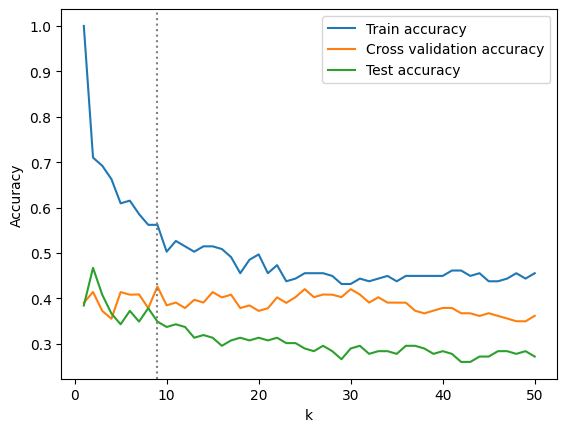

In [30]:
#3 building the model
#I choose k with 5 fold cross validation on the TRAINING data only, so the test set is not used to pick k.
#The pipeline learns the scaling inside each fold, which keeps the validation fold out of the scaling.
ks = np.arange(1, 51)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=65)
cv_acc = []
train_acc = []
test_acc = []   #only used for the plot, NOT used to choose k

for k in ks:
    model = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=int(k)))
    cv_acc.append(cross_val_score(model, X_train, y_train, cv=skf).mean())
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

k_star = int(ks[np.argmax(cv_acc)])
print("k chosen by cross validation:", k_star, "with CV accuracy", round(max(cv_acc), 3))

plt.plot(ks, train_acc, label="Train accuracy")
plt.plot(ks, cv_acc, label="Cross validation accuracy")
plt.plot(ks, test_acc, label="Test accuracy")
plt.axvline(k_star, linestyle=":", color="gray")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
#How I selected k: I tried k from 1 to 50 because the slides used 50, and it is way larger than the best k but way smaller than 169.
#I picked the k with the best cross validation accuracy on the training data. Training accuracy is highest at tiny k (overfitting),
#and test accuracy at k=2 looks good but is a lucky spike, so choosing k from the test set would give an overly optimistic accuracy.

In [31]:
#4 Confusion table
best_model = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=k_star))
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Building the table
cm = pd.crosstab(y_test, y_pred, rownames=["Actual"], colnames=["Predicted"])
print(cm)

# Accuracy test
print("Test accuracy:", round(np.mean(y_pred == y_test), 3))

# Accuracy by mine type
recall = np.diag(cm) / cm.sum(axis=1)      #of the real mines of a type, how many did we catch
precision = np.diag(cm) / cm.sum(axis=0)   #of the mines we called a type, how many were right
print(pd.DataFrame({"recall": recall.round(2), "precision": precision.round(2)}))
#Overall the model is only right about a third of the time (a random guess would be right about 20% of the time).
#Type 2 is the most accurate because its voltage is much higher than the others. Type 1 is okay, but types 3, 4 and 5 are
#poor because their voltages overlap, and many of them get called type 1.

Predicted   1   2   3  4   5
Actual                      
1          21   0   3  6   6
2           1  25   4  0   5
3          12   0   7  4  10
4          13   3   5  4   8
5          11   0  13  6   2
Test accuracy: 0.349
   recall  precision
1    0.58       0.36
2    0.71       0.89
3    0.21       0.22
4    0.12       0.20
5    0.06       0.06


In [2]:
#5
# The model can look good for one type of mine and still make a lot of mistakes.
# For example, it finds 21 of the 36 real type 1 mines (58%), but it predicted
# type 1 a total of 58 times, so only about 36% of those predictions were right.
# Many type 3, 4, and 5 mines get called type 1, and overall accuracy is only about 35%.

# In practice, I would use this model only as a screening tool.
# A type 2 prediction is fairly reliable (about 89% right), but a type 1, 3, 4 or 5
# prediction should be treated as uncertain and handled with the most cautious procedure,
# since calling a dangerous mine harmless costs far more than a false alarm.
# I would also report the vote share (predict_proba) instead of just a label
# and keep a human expert involved.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

In [3]:
# The first main improvement was changing how k was chosen. Cross validation on the training data keeps the test set untouched, so the accuracy estimate is honest. Next, the EDA now includes the target label and shows how the features differ by mine type, especially that type 2 has a higher voltage. However, choosing k with cross validation was more honest, but with only 170 training rows the accuracy differences between k values are small, so k=9 isn't clearly better than nearby values and the lower test accuracy can look like a step in the wrong direction.
# Another improvement that Claude made was fixing a bug in my code. I forgot to define train_acc and Claude also added recall and precision by mine type, which showed where the model was failing.
# To verify the final solution, I reran the Phase 2 code and the confusion table printed 21/36 real type 1 predictions, 58 total type 1 predictions(only 21 were correct), and a 34.9% accuracy overall. This accuracy level is not great, so I would still need to improve the model if this assignment ever got used in the real world.